# PAYG Social Security: Four-Case Comparison

**Four steady states** comparing inelastic vs elastic labour supply,
with and without the PAYG pension ($\tau=0$ vs $\tau=0.3$).

| Case | Labour supply | Pension |
|---|---|---|
| **A** | Inelastic ($\ell=0.3$ fixed) | $\tau=0$ — **reference** |
| **B** | Inelastic ($\ell=0.3$ fixed) | $\tau=0.3$ — PAYG |
| **C** | Elastic (endogenous $\ell$) | $\tau=0$ |
| **D** | Elastic (endogenous $\ell$) | $\tau=0.3$ — PAYG |

**Welfare metric:** CEV relative to Case A (inelastic, no pension):
$$\text{CEV} = \exp\!\left(\frac{U - U_A}{1+\beta_0}\right) - 1$$

**Key economic forces:**
- PAYG crowds out capital (implicit return $n < r$) — Cases A→B and C→D
- Elastic labour adds a second distortion: $\tau$ acts as a wage tax, reducing $\ell$
- With elastic labour at $\tau=0$, the model is calibrated so $\ell^*=0.30$ (same as fixed case)

## Cell 1 — Imports and parameters

In [250]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

In [252]:
import os

# define your output folder
output_dir = r"C:\Users\russale86005\Dropbox\TEACHING\Advanced Macro Fiscal Policies\New_Course_OLG_2026\Lectures\02_pensions_and_public_debt\code\Python\Output"
os.makedirs(output_dir, exist_ok=True)

In [254]:
# ── Parameters ───────────────────────────────────────────────────────────
ls_fixed = 0.3    # fixed labour supply (inelastic cases)
alpha    = 0.36    # capital share
beta0    = 0.40    # discount factor (one period = one generation)
n        = 0.10    # population growth rate
# nu0      = 257.15  # labour disutility scale: standard internal calibration technique. The disutility parameters have no direct empirical counterpart and are not estimated, but they are disciplined by two things that do have empirical counterparts — the aggregate hours target and the Frisch elasticity
nu1      = 3.33    # labour disutility curvature implies a Frisch elasticity of 1/3.33≈0.301
# nu0 and nu1 are calibrated so that optimal labour = 0.30 when tau=0.

## Cell 2 — Factor prices and utility

With Cobb-Douglas production, both $r$ and $w$ depend on the capital-labour
ratio $k/l$:
$$r(k,l) = \alpha\,k^{\alpha-1}l^{1-\alpha}, \qquad
w(k,l) = (1-\alpha)\,k^{\alpha}l^{-\alpha}$$

Lifetime utility:
$$U(c_1,c_2,l) = \ln c_1 + \beta_0\ln c_2 - \frac{\nu_0}{1+\nu_1}\,l^{1+\nu_1}$$

In [259]:
def interest(k, l): return alpha*k**(alpha-1)*l**(1-alpha)
def wage(k, l):     return (1-alpha)*k**alpha*l**(-alpha)

def lifetime_utility(c1, c2, l):
    return np.log(c1) + beta0*np.log(c2) - nu0*l**(1+nu1)/(1+nu1)

print('Factor prices and utility defined.')

Factor prices and utility defined.


## Cell 3 — Inelastic labour: steady-state solver (Cases A and B)

With $\ell = 0.3$ fixed, the young's optimal saving (from the Euler equation)
and capital market clearing $k(1+n)=s$ give Heer's equation (6.19):

$$k(1+n) - \frac{\beta_0}{1+\beta_0}w(k)\ell
+ \frac{1}{1+\beta_0}\cdot\frac{1+\beta_0+\beta_0 r(k)+n}{1+r(k)}\cdot
\underbrace{\tau\,w(k)\,\ell}_{d} = 0$$

With $\tau=0$ this is the standard Diamond (1965) saving equation.

In [262]:
def ksteady_inelastic(k, tau, l=ls_fixed):
    """
    Steady-state capital market clearing condition with fixed labour l.
    Residual = 0 at the fixed point.
    """
    w = wage(k, l); r = interest(k, l)
    d = tau * w * l
    return (k*(1+n)
            - w*l*beta0/(1+beta0)
            + 1/(1+beta0)*(1+beta0+beta0*r+n)/(1+r)*d)

def find_kss_inelastic(tau, l=ls_fixed, kmin=1e-4, kmax=5.0, nk=2000):
    """Grid scan for warm start, then refine with fsolve."""
    k_grid = np.linspace(kmin, kmax, nk)
    res    = np.abs([ksteady_inelastic(k, tau, l) for k in k_grid])
    k_init = k_grid[np.argmin(res)]
    return float(fsolve(lambda k: ksteady_inelastic(k, tau, l), k_init)[0])

def compute_ss_inelastic(tau, l=ls_fixed):
    """Full steady-state computation for inelastic labour."""
    k  = find_kss_inelastic(tau, l)
    w  = wage(k, l); r = interest(k, l); d = tau*w*l
    c1 = 1/(1+beta0)*(w*l + (n-r)/(1+r)*d)
    c2 = beta0*c1*(1+r)
    y  = k**alpha * l**(1-alpha)
    U  = lifetime_utility(c1, c2, l)
    return dict(k=k, l=l, y=y, w=w, r=r, c1=c1, c2=c2, U=U)

print('Inelastic labour solver defined.')

Inelastic labour solver defined.


### Internal calibration of $\nu_0$

$\nu_0$ has no direct empirical counterpart. We pin it down by requiring that optimal labour equals `ls_fixed = 0.30` at the no-pension steady state — using the *inelastic* solver for $k^*$, then inverting the static labour FOC. This must run **after** the inelastic solver has been defined, because the calibration calls `ksteady_inelastic` and `wage`.

In [256]:
# ── Calibrate nu0 internally ──────────────────────────────────────────────
# nu0 has no direct empirical counterpart. It is pinned by requiring that
# optimal labour equals ls_fixed = 0.30 at the no-pension steady state.
#
# Steps:
#   1. Find k* from capital market clearing at tau=0 (nu0 does not enter
#      the inelastic version, so k* is independent of nu0).
#   2. At k*, compute w* and c1* from the household's budget.
#   3. Invert the static labour FOC:  nu0 * l^nu1 = w / c1
#      => nu0 = w* / (c1* * ls_fixed^nu1)

def calibrate_nu0(l_target=ls_fixed, tau=0.0):
    # Step 1: find no-pension SS capital
    k_grid = np.linspace(1e-4, 5.0, 2000)
    res    = np.abs([ksteady_inelastic(k, tau, l_target) for k in k_grid])
    k_init = k_grid[np.argmin(res)]
    k_star = float(fsolve(lambda k: ksteady_inelastic(k, tau, l_target), k_init)[0])

    # Step 2: factor prices and young's consumption at k*
    w_star  = wage(k_star, l_target)
    r_star  = interest(k_star, l_target)
    c1_star = 1/(1+beta0) * w_star * l_target   # simplified: tau=0 => d=0

    # Step 3: invert FOC   nu0 * l^nu1 = w / c1
    return w_star / (c1_star * l_target**nu1)

nu0 = calibrate_nu0()
print(f'nu0 calibrated = {nu0:.4f}  (Frisch elasticity = {1/nu1:.3f})')

nu0 calibrated = 257.1538  (Frisch elasticity = 0.300)


## Cell 4 — Elastic labour: optimal labour supply (Cases C and D)

With endogenous $\ell$, the household maximises:
$$\max_{c_1,c_2,\ell}\; \ln c_1 + \beta_0\ln c_2
- \frac{\nu_0}{1+\nu_1}\ell^{1+\nu_1}$$

The static first-order condition for labour (intratemporal optimality):
$$\nu_0\,\ell^{\nu_1} = \frac{(1-\tau)w}{c_1}$$

Combined with the budget constraint $c_1(1+\beta_0) = w\,\ell\,B$
(where $B = (1-\tau) + \tau(1+n)/(1+r)$ collects pension present values),
this gives one implicit equation in $\ell$ given $(k, \tau)$:
$$\nu_0\,\ell^{\nu_1+1}\,B(k,\tau,\ell) = (1-\tau)(1+\beta_0)$$

Because $r$ and $w$ both depend on $\ell$ (through the $k/l$ ratio),
this is solved numerically for each $k$.

In [265]:
def labour_optimal(k, tau):
    """
    Endogenous labour supply as a function of k and tau.
    Solves the static FOC: nu0*l^nu1 = (1-tau)*w(k,l) / c1(k,l,tau)
    where c1 = w*l*B/(1+beta0)  and  B = (1-tau) + tau*(1+n)/(1+r).
    """
    def foc(l):
        if l <= 1e-6: return 1e10
        w = wage(k, l)
        r = interest(k, l)
        B  = (1-tau) + tau*(1+n)/(1+r)   # pension present-value factor
        c1 = w*l*B/(1+beta0)             # budget: c1*(1+beta0) = w*l*B
        if c1 <= 0: return 1e10
        # FOC: nu0*l^nu1 - (1-tau)*w/c1 = 0
        return nu0*l**nu1 - (1-tau)*w/c1
    return max(1e-4, float(fsolve(foc, ls_fixed)[0]))

def ksteady_elastic(k, tau):
    """Steady-state condition with elastic labour."""
    l = labour_optimal(k, tau)
    return ksteady_inelastic(k, tau, l)   # same formula, but l is now endogenous

def find_kss_elastic(tau, kmin=1e-4, kmax=5.0, nk=2000):
    k_grid = np.linspace(kmin, kmax, nk)
    res    = np.abs([ksteady_elastic(k, tau) for k in k_grid])
    k_init = k_grid[np.argmin(res)]
    return float(fsolve(lambda k: ksteady_elastic(k, tau), k_init)[0])

def compute_ss_elastic(tau):
    """Full steady-state computation for elastic labour."""
    k  = find_kss_elastic(tau)
    l  = labour_optimal(k, tau)
    w  = wage(k, l); r = interest(k, l); d = tau*w*l
    B  = (1-tau) + tau*(1+n)/(1+r)
    c1 = w*l*B/(1+beta0)
    c2 = beta0*c1*(1+r)
    y  = k**alpha * l**(1-alpha)
    U  = lifetime_utility(c1, c2, l)
    return dict(k=k, l=l, y=y, w=w, r=r, c1=c1, c2=c2, U=U)

print('Elastic labour solver defined.')

Elastic labour solver defined.


## Cell 5 — Compute all four steady states

In [268]:
print('Computing four steady states ...')
A = compute_ss_inelastic(0.0)   # reference
B = compute_ss_inelastic(0.3)
C = compute_ss_elastic(0.0)
D = compute_ss_elastic(0.3)

print(f'Case A (inelastic, tau=0):   k={A["k"]:.4f}  l={A["l"]:.4f}')
print(f'Case B (inelastic, tau=0.3): k={B["k"]:.4f}  l={B["l"]:.4f}')
print(f'Case C (elastic,   tau=0):   k={C["k"]:.4f}  l={C["l"]:.4f}')
print(f'Case D (elastic,   tau=0.3): k={D["k"]:.4f}  l={D["l"]:.4f}')
print()
print('Note: Case C gives l=0.30 exactly -- confirms nu0,nu1 calibration is correct.')

Computing four steady states ...
Case A (inelastic, tau=0):   k=0.0182  l=0.3000
Case B (inelastic, tau=0.3): k=0.0069  l=0.3000
Case C (elastic,   tau=0):   k=0.0182  l=0.3000
Case D (elastic,   tau=0.3): k=0.0067  l=0.2939

Note: Case C gives l=0.30 exactly -- confirms nu0,nu1 calibration is correct.


## Cell 6 — Summary table

CEV (consumption-equivalent variation) is always relative to **Case A** (the reference):
$$\text{CEV}_x = \exp\!\left(\frac{U_x - U_A}{1+\beta_0}\right) - 1$$

In [271]:
def cev(U, U_ref=A['U']):
    return np.exp((U - U_ref)/(1+beta0)) - 1

cases  = [A, B, C, D]
labels = ['(A) Inelastic  tau=0  [ref]',
          '(B) Inelastic  tau=0.3',
          '(C) Elastic    tau=0',
          '(D) Elastic    tau=0.3']

# ── Print table ──────────────────────────────────────────────────────────
col = 22
print()
print('='*(col + 4*17))
print('  PAYG STEADY-STATE COMPARISON   (reference: Case A)')
print('='*(col + 4*17))
header = f'  {"":^{col}}' + ''.join(f'{lb:>17}' for lb in labels)
print(header)
print('  ' + '-'*(col + 4*17 - 2))

rows = [
    ('Capital  k',          'k',   4, False),
    ('Labour   l',          'l',   4, False),
    ('Output   y',          'y',   4, False),
    ('Wage     w',          'w',   4, False),
    ('Interest r (%)',       'r',   2, True),
    ('Consumption  c1',     'c1',  4, False),
    ('Consumption  c2',     'c2',  4, False),
    ('Lifetime utility  U', None,  4, False),
    ('CEV vs Case A  (%)',   None,  2, False),
]

for label, key, dp, pct in rows:
    if label.startswith('CEV'):
        vals = [0.0] + [cev(ss['U'])*100 for ss in cases[1:]]
        line = f'  {label:<{col}}' + f'  {"[0.00]":>15}'
        for v in vals[1:]: line += f'{v:>17.{dp}f}'
    elif key is None:
        vals = [ss['U'] for ss in cases]
        line = f'  {label:<{col}}'
        for v in vals: line += f'{v:>17.{dp}f}'
    else:
        if pct: vals = [ss[key]*100 for ss in cases]
        else:   vals = [ss[key]     for ss in cases]
        line = f'  {label:<{col}}'
        for v in vals: line += f'{v:>17.{dp}f}'
    print(line)

print('  ' + '-'*(col + 4*17 - 2))
print()
print('  Notes:')
print('  - Cases A,B: ell=0.30 fixed throughout')
print('  - Cases C,D: ell endogenous from static FOC')
print('  - nu0,nu1 calibrated so that ell*=0.30 in Case C (tau=0, elastic)')
print('  - PAYG crowds out capital in both inelastic and elastic cases')
print('  - Elastic labour adds an extra margin: tau acts as a wage tax, reducing ell')
print('  - Welfare loss is larger in Case D than B because of the labour distortion')


  PAYG STEADY-STATE COMPARISON   (reference: Case A)
                        (A) Inelastic  tau=0  [ref](B) Inelastic  tau=0.3(C) Elastic    tau=0(D) Elastic    tau=0.3
  ----------------------------------------------------------------------------------------
  Capital  k                       0.0182           0.0069           0.0182           0.0067
  Labour   l                       0.3000           0.3000           0.3000           0.2939
  Output   y                       0.1093           0.0770           0.1093           0.0754
  Wage     w                       0.2333           0.1643           0.2333           0.1643
  Interest r (%)                   216.56           403.84           216.56           403.84
  Consumption  c1                  0.0500           0.0269           0.0500           0.0264
  Consumption  c2                  0.0633           0.0543           0.0633           0.0532
  Lifetime utility  U             -4.4234          -5.1023          -4.4234          -5.

## Cell 7 — Figures

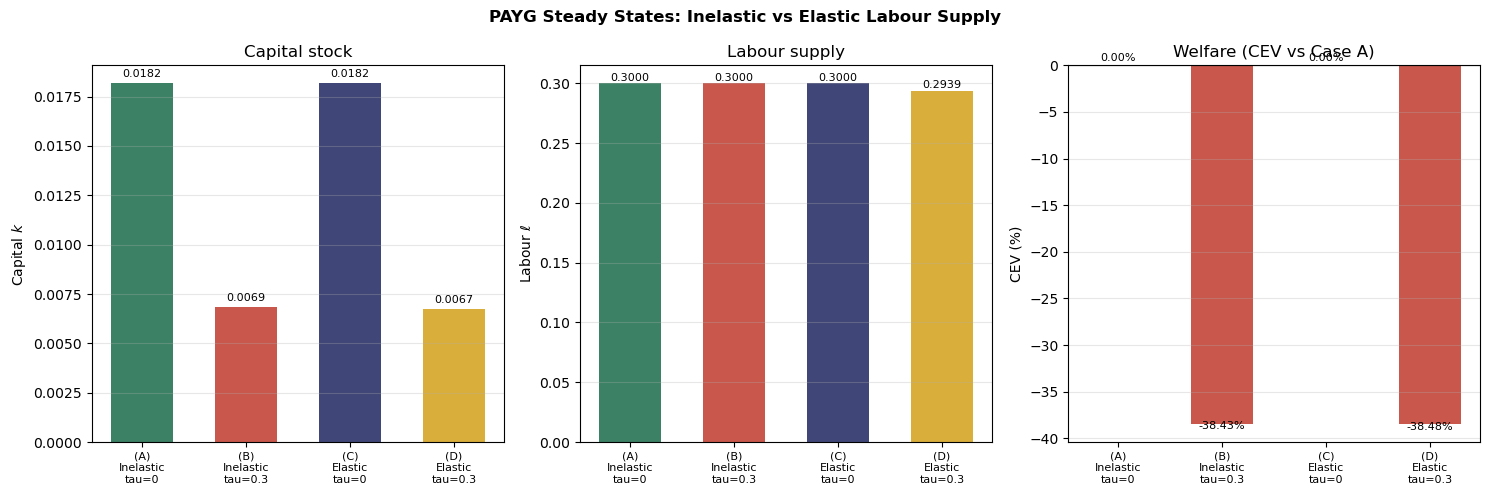

Done.


In [276]:
NAVY  = '#1E2761'; RED = '#C0392B'; GREEN = '#1A6B4A'; AMBER = '#D4A017'
colors = [GREEN, RED, NAVY, AMBER]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('PAYG Steady States: Inelastic vs Elastic Labour Supply',
             fontsize=12, fontweight='bold')

xlabels = ['(A)\nInelastic\ntau=0', '(B)\nInelastic\ntau=0.3',
           '(C)\nElastic\ntau=0', '(D)\nElastic\ntau=0.3']
x = np.arange(4)

# Capital
ax = axes[0]
bars = ax.bar(x, [ss['k'] for ss in cases], color=colors, alpha=0.85, width=0.6)
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel('Capital $k$'); ax.set_title('Capital stock')
ax.grid(axis='y', alpha=0.3)
for bar, ss in zip(bars, cases):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
            f'{ss["k"]:.4f}', ha='center', va='bottom', fontsize=8)

# Labour
ax = axes[1]
bars = ax.bar(x, [ss['l'] for ss in cases], color=colors, alpha=0.85, width=0.6)
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel('Labour $\ell$'); ax.set_title('Labour supply')
ax.grid(axis='y', alpha=0.3)
for bar, ss in zip(bars, cases):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
            f'{ss["l"]:.4f}', ha='center', va='bottom', fontsize=8)

# CEV
ax = axes[2]
cev_vals = [0.0, cev(B['U'])*100, cev(C['U'])*100, cev(D['U'])*100]
bar_colors = [GREEN if v >= 0 else RED for v in cev_vals]
bars = ax.bar(x, cev_vals, color=bar_colors, alpha=0.85, width=0.6)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel('CEV (%)'); ax.set_title('Welfare (CEV vs Case A)')
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, cev_vals):
    offset = 0.3 if v >= 0 else -0.8
    ax.text(bar.get_x()+bar.get_width()/2, v+offset,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(output_dir, "comparison_ss_elastic.png"), dpi=150, bbox_inches='tight')
plt.show()
print('Done.')

## Cell 8 — Transition dynamics after PAYG abolition

Simulates the 20-period path after the pension system is abolished.

**Generational timing:**

| Period | Young pays τ₀ | Young receives pension |
|---|---|---|
| t=1 | 0.30 | Yes (PAYG still in force) |
| t=2 | 0.30 | **No** — transition generation: pays but receives nothing |
| t≥3 | **0** | No — fully free of PAYG |

**Plot 1:** Capital $k_t$, Labour $\ell_t$, Interest rate $r_t$ and the internal rate of the pension system $n$ along the transition, comparing inelastic vs elastic labour supply.

**Plot 2:** CEV relative to the no-pension inelastic benchmark (Case A), comparing inelastic vs elastic labour supply across birth cohorts.

In [278]:
# ── Transition dynamics ────────────────────────────────────────────────────
nt = 10   # number of transition periods

# Internal rate of the pension system (= population growth rate n)
# This is the return a participant earns from the PAYG system.
pension_internal_rate = n   # constant = 0.10

# ── kdyn: capital market clearing across two adjacent periods ──────────────
def kdyn_inelastic(k1, k0, tau0, tau1, l=ls_fixed):
    """Residual of capital market clearing with fixed labour l."""
    w0 = wage(k0, l); w1 = wage(k1, l); r1 = interest(k1, l)
    d1 = tau1 * w1 * l
    return (k1*(1+n)
            - (1-tau0)*w0*l*beta0/(1+beta0)
            + 1/(1+beta0)*(1+n)/(1+r1)*d1)

def kdyn_elastic(k1, k0, tau0, tau1):
    """Residual of capital market clearing with endogenous labour."""
    l0 = labour_optimal(k0, tau0)
    l1 = labour_optimal(k1, tau1)
    w0 = wage(k0, l0); w1 = wage(k1, l1); r1 = interest(k1, l1)
    d1 = tau1 * w1 * l1
    return (k1*(1+n)
            - (1-tau0)*w0*l0*beta0/(1+beta0)
            + 1/(1+beta0)*(1+n)/(1+r1)*d1)

# ── Run inelastic transition (starting from PAYG SS = Case B) ─────────────
def run_transition_inelastic():
    kt = np.zeros(nt+1); utilt = np.zeros(nt+1); cect = np.zeros(nt+1)
    lt = np.full(nt+1, ls_fixed)           # labour is always fixed
    rt = np.zeros(nt+1)

    kt[0]    = B['k']
    utilt[0] = B['U']
    cect[0]  = cev(B['U'])
    rt[0]    = interest(B['k'], ls_fixed)

    tau0 = 0.3; tau1 = 0.3
    for i in range(nt):
        if i == 1: tau1 = 0.0    # transition gen: pays but receives nothing
        elif i == 2: tau0 = 0.0  # first fully free generation

        k0 = kt[i]
        k1 = fsolve(lambda k: kdyn_inelastic(k, k0, tau0, tau1), k0)[0]

        d0 = tau0 * wage(k0, ls_fixed) * ls_fixed
        d1 = tau1 * wage(k1, ls_fixed) * ls_fixed
        c1 = 1/(1+beta0)*(wage(k0,ls_fixed)*ls_fixed - d0
                          + d1*(1+n)/(1+interest(k1,ls_fixed)))
        c2 = beta0*c1*(1+interest(k1,ls_fixed))

        utilt[i+1] = lifetime_utility(c1, c2, ls_fixed)
        cect[i+1]  = cev(utilt[i+1])
        kt[i+1]    = k1
        rt[i+1]    = interest(k1, ls_fixed)

    return kt, lt, rt, cect

# ── Run elastic transition (starting from PAYG SS = Case D) ───────────────
def run_transition_elastic():
    kt = np.zeros(nt+1); lt = np.zeros(nt+1)
    utilt = np.zeros(nt+1); cect = np.zeros(nt+1)
    rt = np.zeros(nt+1)

    kt[0]    = D['k']
    lt[0]    = D['l']
    utilt[0] = D['U']
    cect[0]  = cev(D['U'])
    rt[0]    = interest(D['k'], D['l'])

    tau0 = 0.3; tau1 = 0.3
    for i in range(nt):
        if i == 1: tau1 = 0.0
        elif i == 2: tau0 = 0.0

        k0 = kt[i]
        k1 = fsolve(lambda k: kdyn_elastic(k, k0, tau0, tau1), k0)[0]
        l0 = labour_optimal(k0, tau0)
        l1 = labour_optimal(k1, tau1)

        d0 = tau0 * wage(k0, l0) * l0
        d1 = tau1 * wage(k1, l1) * l1
        c1 = 1/(1+beta0)*(wage(k0,l0)*l0 - d0
                          + d1*(1+n)/(1+interest(k1,l1)))
        c2 = beta0*c1*(1+interest(k1,l1))

        utilt[i+1] = lifetime_utility(c1, c2, l1)
        cect[i+1]  = cev(utilt[i+1])
        kt[i+1]    = k1
        lt[i+1]    = l1
        rt[i+1]    = interest(k1, l1)

    return kt, lt, rt, cect

print('Running inelastic transition ...')
kt_inel, lt_inel, rt_inel, cect_inel = run_transition_inelastic()
print('Running elastic transition ...')
kt_el,   lt_el,   rt_el,   cect_el   = run_transition_elastic()
print('Done.')

# ── Verify ─────────────────────────────────────────────────────────────────
periods = np.arange(nt+1)
print(f'\nInelastic: k_0={kt_inel[0]:.4f} -> k_20={kt_inel[-1]:.4f}')
print(f'Elastic:   k_0={kt_el[0]:.4f}   -> k_20={kt_el[-1]:.4f}')
print(f'Transition gen CEV — inelastic: {cect_inel[2]*100:.2f}%  elastic: {cect_el[2]*100:.2f}%')


Running inelastic transition ...
Running elastic transition ...
Done.

Inelastic: k_0=0.0069 -> k_20=0.0182
Elastic:   k_0=0.0067   -> k_20=0.0182
Transition gen CEV — inelastic: -45.82%  elastic: -46.77%


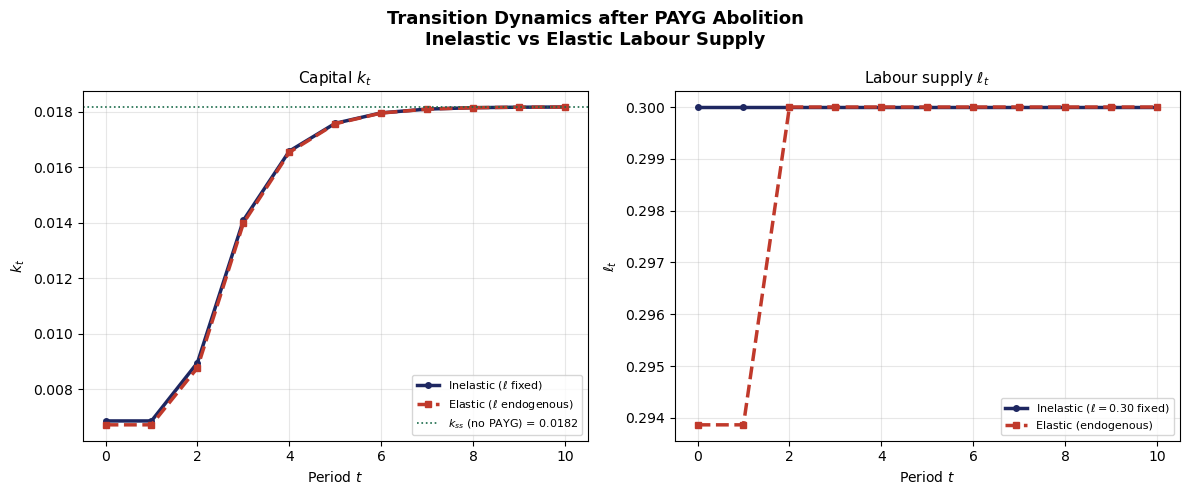

Plot 1 done.


In [282]:
NAVY  = '#1E2761'
RED   = '#C0392B'
GREEN = '#1A6B4A'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))   # fix 1: correct figsize
fig.suptitle(
    'Transition Dynamics after PAYG Abolition\n'
    'Inelastic vs Elastic Labour Supply',
    fontsize=13, fontweight='bold')

# ── Panel 1: Capital ─────────────────────────────────────────────────────
ax = axes[0]                                        # fix 2: assign ax
ax.plot(periods, kt_inel, color=NAVY, lw=2.5, marker='o', ms=4,
        label='Inelastic ($\\ell$ fixed)')
ax.plot(periods, kt_el,   color=RED,  lw=2.5, marker='s', ms=4, ls='--',
        label='Elastic ($\\ell$ endogenous)')
ax.axhline(A['k'], color=GREEN, lw=1.2, ls=':',
           label=f"$k_{{ss}}$ (no PAYG) = {A['k']:.4f}")
ax.set_title('Capital $k_t$', fontsize=11)
ax.set_xlabel('Period $t$'); ax.set_ylabel('$k_t$')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: Labour ──────────────────────────────────────────────────────
ax = axes[1]                                        # fix 2: assign ax
ax.plot(periods, lt_inel, color=NAVY, lw=2.5, marker='o', ms=4,
        label='Inelastic ($\\ell=0.30$ fixed)')
ax.plot(periods, lt_el,   color=RED,  lw=2.5, marker='s', ms=4, ls='--',
        label='Elastic (endogenous)')
ax.set_title('Labour supply $\\ell_t$', fontsize=11)
ax.set_xlabel('Period $t$'); ax.set_ylabel('$\\ell_t$')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(output_dir, "transition_elastic.png"), dpi=150, bbox_inches='tight')

plt.show()
print('Plot 1 done.')


Welfare summary:
  Inelastic: transition gen (t=2) CEV = -45.82%  | long-run (t=20) CEV = -0.02%
  Elastic:   transition gen (t=2) CEV = -46.77%  | long-run (t=20) CEV = -0.02%

Note: Elastic labour amplifies the welfare loss for the transition generation
because abolishing PAYG also removes the implicit wage-tax distortion,
which means labour jumps up immediately — but only after the transition gen
has already paid their contributions.


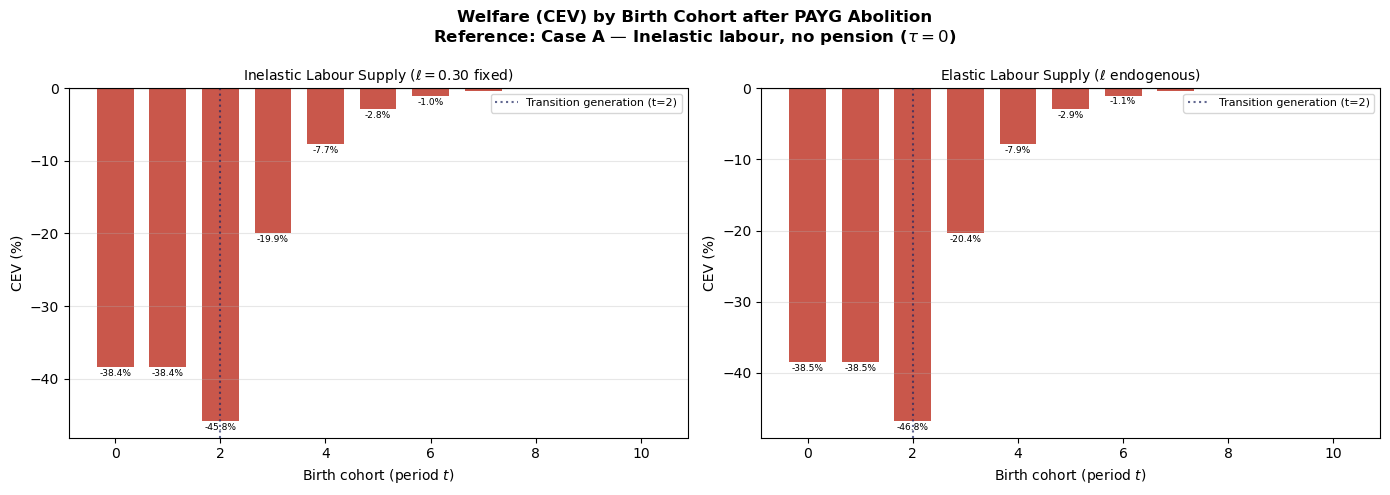

Plot 2 done.


In [284]:
# ── Plot 2: CEV across birth cohorts — inelastic vs elastic ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle(
    'Welfare (CEV) by Birth Cohort after PAYG Abolition\n'
    'Reference: Case A — Inelastic labour, no pension ($\\tau=0$)',
    fontsize=12, fontweight='bold')

NAVY  = '#1E2761'
RED   = '#C0392B'
GREEN = '#1A6B4A'

# ── Panel 1: Inelastic ──────────────────────────────────────────────────
ax = axes[0]
bar_colors = [GREEN if v >= 0 else RED for v in cect_inel]
ax.bar(periods, cect_inel * 100, color=bar_colors, alpha=0.85, width=0.7)
ax.axhline(0, color='k', lw=0.8)
ax.axvline(2, color=NAVY, ls=':', lw=1.5, alpha=0.7,
           label='Transition generation (t=2)')
ax.set_title('Inelastic Labour Supply ($\ell = 0.30$ fixed)', fontsize=10)
ax.set_xlabel('Birth cohort (period $t$)')
ax.set_ylabel('CEV (%)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(cect_inel * 100):
    if abs(v) > 1:
        ax.text(i, v + (0.3 if v >= 0 else -1.5),
                f'{v:.1f}%', ha='center', va='bottom', fontsize=6.5, color='black')

# ── Panel 2: Elastic ────────────────────────────────────────────────────
ax = axes[1]
bar_colors = [GREEN if v >= 0 else RED for v in cect_el]
ax.bar(periods, cect_el * 100, color=bar_colors, alpha=0.85, width=0.7)
ax.axhline(0, color='k', lw=0.8)
ax.axvline(2, color=NAVY, ls=':', lw=1.5, alpha=0.7,
           label='Transition generation (t=2)')
ax.set_title('Elastic Labour Supply ($\ell$ endogenous)', fontsize=10)
ax.set_xlabel('Birth cohort (period $t$)')
ax.set_ylabel('CEV (%)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(cect_el * 100):
    if abs(v) > 1:
        ax.text(i, v + (0.3 if v >= 0 else -1.5),
                f'{v:.1f}%', ha='center', va='bottom', fontsize=6.5, color='black')

# ── Summary annotation ───────────────────────────────────────────────────
print('\nWelfare summary:')
print(f'  Inelastic: transition gen (t=2) CEV = {cect_inel[2]*100:.2f}%  '
      f'| long-run (t=20) CEV = {cect_inel[-1]*100:.2f}%')
print(f'  Elastic:   transition gen (t=2) CEV = {cect_el[2]*100:.2f}%  '
      f'| long-run (t=20) CEV = {cect_el[-1]*100:.2f}%')
print()
print('Note: Elastic labour amplifies the welfare loss for the transition generation')
print('because abolishing PAYG also removes the implicit wage-tax distortion,')
print('which means labour jumps up immediately — but only after the transition gen')
print('has already paid their contributions.')

plt.tight_layout()
fig.savefig(os.path.join(output_dir, "CEV_comparison.png"), dpi=150, bbox_inches='tight')

plt.show()
print('Plot 2 done.')
